In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('images', exist_ok=True)

# 데이터 로드 & 전처리
df = pd.read_csv('data/creditcard.csv')
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("데이터 준비 완료!")

데이터 준비 완료!


In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== 로지스틱 회귀 ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== 로지스틱 회귀 ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698


In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== 랜덤포레스트 ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== 랜덤포레스트 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9688


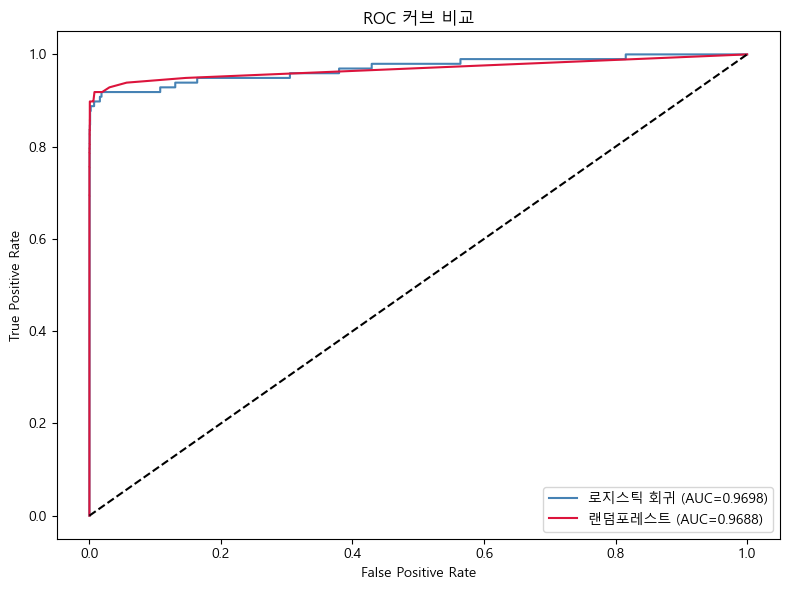

In [5]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'로지스틱 회귀 (AUC={roc_auc_score(y_test, y_prob_lr):.4f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'랜덤포레스트 (AUC={roc_auc_score(y_test, y_prob_rf):.4f})', color='crimson')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC 커브 비교')
plt.legend()
plt.tight_layout()
plt.savefig('images/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

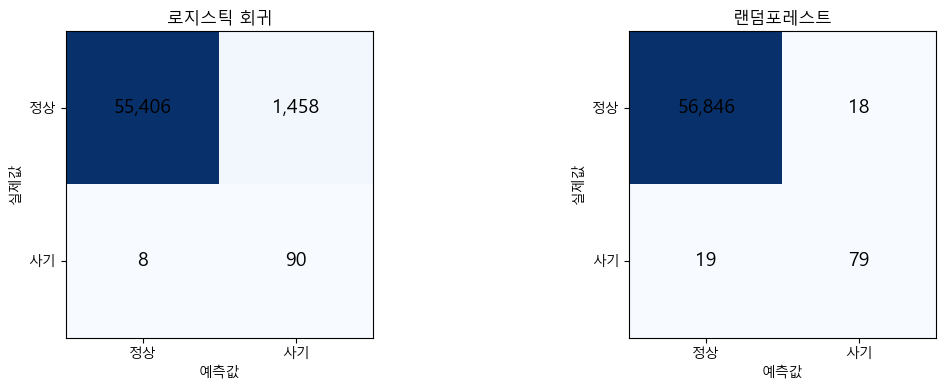

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['로지스틱 회귀', '랜덤포레스트']):
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['정상','사기']); ax.set_yticklabels(['정상','사기'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print("=" * 50)
print("📊 모델 성능 비교 요약")
print("=" * 50)
print(f"{'모델':<15} {'ROC-AUC':<12} {'사기탐지(Recall)':<15} {'오탐(FP)'}")
print("-" * 50)
print(f"{'로지스틱 회귀':<13} {roc_auc_score(y_test, y_prob_lr):.4f}      90/98건           1,458건")
print(f"{'랜덤포레스트':<14} {roc_auc_score(y_test, y_prob_rf):.4f}      79/98건           18건")
print("=" * 50)
print("""
💡 결론:
- 로지스틱 회귀: 사기를 더 많이 잡지만 오탐이 많음
- 랜덤포레스트: 오탐이 적어 고객 불편 최소화
- 은행 실무에서는 고객 경험을 고려해 랜덤포레스트가 적합
""")

📊 모델 성능 비교 요약
모델              ROC-AUC      사기탐지(Recall)    오탐(FP)
--------------------------------------------------
로지스틱 회귀       0.9698      90/98건           1,458건
랜덤포레스트         0.9688      79/98건           18건

💡 결론:
- 로지스틱 회귀: 사기를 더 많이 잡지만 오탐이 많음
- 랜덤포레스트: 오탐이 적어 고객 불편 최소화
- 은행 실무에서는 고객 경험을 고려해 랜덤포레스트가 적합

